# Problem Statement
The goal of this notebook is to analyze the budget allocations and actual expenditure of local bodies in all Provinces for FY 2021-22.
I want to identify major spending categories, compare budget vs realized expense at province and local-body levels, and highlight disparities between urban and rural local bodies.

# Objectives
- Load and clean the budget and expenditure data.
- Visualize composition of budgets and expenditures (recurrent, capital, financial).
- Measure utilization (expense / budget) at province and local-body levels.
- Identify top and bottom local bodies by spending.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
file_path = "../data/Expenditure-of-local-bodies.xlsx"
if not os.path.exists(file_path):
    print("Dataset not found!")
else:
    print("Good to go!😊")

Good to go!😊


In [3]:
from feature_engineering import FeatureExtraction, FeatureExtractionTotal, FeatureExtractionUrban
from visualization import PerformanceAnalysis, CompositionAnalysis, PieCharts

In [4]:
feature_extraction = FeatureExtraction(fname=file_path) # Instantiation , default province - Bagmati
all_content_df = feature_extraction.open_file().copy() # Extracts all content of file as pd dataframe
all_content_df_renamed = feature_extraction.rename_label(dataframe=all_content_df).copy() # labels renamed after extraction
province3_rows = feature_extraction.extract_rows_for_province(dataframe=all_content_df_renamed).copy() # Default province
budget_df_province3 = feature_extraction.extract_budget_frame(dataframe=province3_rows).copy() # Extracting budget and exp as separate dataframe
expense_df_province3 = feature_extraction.extract_expenditure_frame(dataframe=province3_rows).copy()
budget_df_all = feature_extraction.extract_budget_frame(dataframe=all_content_df_renamed).copy() # budget frame for all provinces
expense_df_all = feature_extraction.extract_expenditure_frame(dataframe=all_content_df_renamed) # Expense frame for all provinces

# ----------------------------------------------------

print("shape of Bagmati Province frame: ", budget_df_province3.shape)
print("Shape of total frame : ", budget_df_all.shape)

budget_df_province3.head()


shape of Bagmati Province frame:  (120, 7)
Shape of total frame :  (767, 7)


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
277,274,Jiri Municipality,32.1781,21.796821,0.0,53.974921,5.259159
278,275,Bhimeshwor Municipality,40.456662,53.925065,0.15,94.531727,6.743792
279,276,Kalinchwok Rural Municipality,43.495598,30.00791,0.0,73.503508,8.158327
280,277,Gaurisahnkar Rural Municipality,29.82713,20.8173,0.0,50.64443,4.510428
281,278,Tamakoshi Rural Municipality,44.341532,26.595364,0.0,70.936896,17.064383


In [5]:
expense_df_all.head(8)

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,23.587589,15.188281,0.0,38.775871,2.881517
5,6,Mauwakhola Rural Municipality,18.164198,13.060848,0.0,31.225046,4.327077
6,7,Pathibhara Yangwarak Rural Municipality,23.399494,13.367955,0.0,36.767449,6.686506
7,8,Sidingwa Rural Municipality,24.468454,9.661338,0.0,34.129792,5.39351


In [6]:
feature_extraction_urban = FeatureExtractionUrban(df=budget_df_all)
budget_df_urban = feature_extraction_urban.extract_urban_features().copy()
rows, cols = budget_df_urban.shape
budget_df_urban.head(rows)

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
385,382,Kathmandu Metropolitan,546.5301,972.5085,37.1128,1556.1514,983.660309
427,422,Pokhara Metropolitan,246.9233,303.902109,1.0,551.825409,135.404153
358,355,Bharatpur Metropolitan,197.692678,292.229399,0.0,489.922077,163.427313
108,109,Biratnagar Metropolitan,174.652121,244.49391,6.0,425.146032,46.12698
379,376,Lalitpur Metropolitan,142.927227,273.752645,0.0,416.679872,181.757992
261,260,Birjung Metropolitan,167.528752,227.707235,0.0,395.235988,51.231338
365,362,Hetauda Sub-Metropolitan,119.985973,133.746327,0.6,254.3323,105.282164
492,485,Butwal Sub-Metropolitan,95.071215,143.96167,0.6,239.632885,68.785717
568,561,Ghorahi Sub-Metropolitan,121.411407,105.483594,0.0,226.895002,33.644931
569,562,Tulsipur Sub-Metropolitan,109.686715,100.887985,0.633074,211.207773,25.431784


```python
feature_extraction_urban.extract_urban_features()
```
Returns the features of  Metropolitan and Sub-Metropolitan local body only.

---
**Observation**: 
- Metropolitan City: 6
- Sub-metropolitan Cities: 11

In [7]:
feature_extraction_urban = FeatureExtractionUrban(df=budget_df_all) # for all 753 local bodies
budget_df_urban_all = feature_extraction_urban.extract_urban_features().copy()
rows, column = budget_df_urban_all.shape
print("Number of rows : ", rows)
budget_df_urban_all.head(rows)

Number of rows :  17


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
385,382,Kathmandu Metropolitan,546.5301,972.5085,37.1128,1556.1514,983.660309
427,422,Pokhara Metropolitan,246.9233,303.902109,1.0,551.825409,135.404153
358,355,Bharatpur Metropolitan,197.692678,292.229399,0.0,489.922077,163.427313
108,109,Biratnagar Metropolitan,174.652121,244.49391,6.0,425.146032,46.12698
379,376,Lalitpur Metropolitan,142.927227,273.752645,0.0,416.679872,181.757992
261,260,Birjung Metropolitan,167.528752,227.707235,0.0,395.235988,51.231338
365,362,Hetauda Sub-Metropolitan,119.985973,133.746327,0.6,254.3323,105.282164
492,485,Butwal Sub-Metropolitan,95.071215,143.96167,0.6,239.632885,68.785717
568,561,Ghorahi Sub-Metropolitan,121.411407,105.483594,0.0,226.895002,33.644931
569,562,Tulsipur Sub-Metropolitan,109.686715,100.887985,0.633074,211.207773,25.431784


**Observation**:
- Metropolitan City: 6
- Sub-metropolitan Cities: 11

In [8]:
feature_extraction_total = FeatureExtractionTotal(budget_frame=budget_df_all, exp_frame=expense_df_all) 
budget_df_total, expense_df_total = feature_extraction_total.extract_total() # Extracts total for each provinces 
rows, cols = budget_df_total.shape
budget_df_total.head(rows)

Index extracted 😍
Frame for total extracted 😍
Successful 😍


,Province,Recurrent,Capital,Financial,Total,Cash Balance
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
675,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444
765,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354


In [9]:
budget_df_total_sorted = budget_df_total.sort_values(by="Total", ascending=False).copy() # Sorting total
budget_df_total_sorted.head(8)

,Province,Recurrent,Capital,Financial,Total,Cash Balance
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
765,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354
675,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444


In [10]:
SD_for_total = budget_df_total["Total"].std(axis=0)
SD_for_cash_balance = budget_df_total["Cash Balance"].std(axis=0)
mean_for_total = budget_df_total["Total"].mean(axis=0)
mean_for_cash_balance = budget_df_total["Cash Balance"].mean(axis=0)
print("Dispersion measurement : ")
print("For total : ", SD_for_total)
print("For cash balance : ", SD_for_cash_balance)
print("-------------------------------------------------------------------------")
print("Mean measurement : ")
print("For total : ", mean_for_total)
print("For cash balance : ", mean_for_cash_balance)

Dispersion measurement : 
For total :  2870.0771875588407
For cash balance :  1033.4087567596075
-------------------------------------------------------------------------
Mean measurement : 
For total :  7614.052231848856
For cash balance :  1450.9653367797143


In [11]:
max_total = budget_df_total["Total"].max()
min_total = budget_df_total["Total"].min()
rate_mes_for_max = max_total/mean_for_total
rate_mes_for_min = min_total/mean_for_total
print(f"Budget for bagmati province is {rate_mes_for_max} times the mean.")
print(f"Budget for karnali province is {rate_mes_for_min} times the mean.")

Budget for bagmati province is 1.6334039883009928 times the mean.
Budget for karnali province is 0.550384840361335 times the mean.


In [12]:
budget_df_total_reset_index = budget_df_total.reset_index(drop=True).copy()
rows , cols = budget_df_total_reset_index.shape
budget_df_total_reset_index.head(rows)

,Province,Recurrent,Capital,Financial,Total,Cash Balance
0,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
1,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
2,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
3,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
4,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
5,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444
6,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354


In [13]:
budget_df_total_reset_index_sorted = budget_df_total_reset_index.sort_values(by="Cash Balance", ascending=False).copy()
rows, cols = budget_df_total_reset_index_sorted.shape

max_capital = budget_df_total_reset_index_sorted["Capital"].max()
min_capital = budget_df_total_reset_index_sorted["Capital"].min()
ratio_capital = max_capital/min_capital

max_cash_balance = budget_df_total_reset_index_sorted["Cash Balance"].max()
min_cash_balance = budget_df_total_reset_index_sorted["Cash Balance"].min()
ratio_cash_balance = max_cash_balance/min_cash_balance

print(f"Capital of Bagmati is {ratio_capital} times that of Karnali..")
print(f"Cash balance of Bagmati is {ratio_cash_balance} times of Karnali..")
budget_df_total_reset_index_sorted.head(rows)

Capital of Bagmati is 3.920992915326036 times that of Karnali..
Cash balance of Bagmati is 7.064801983516985 times of Karnali..


,Province,Recurrent,Capital,Financial,Total,Cash Balance
2,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
1,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
4,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
0,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
3,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
6,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354
5,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444


**Observation**:
- Bagmati at first position with total capital 6653.58 and Cash balance 3564.23
- Karnali at last position with total capital 1696.91 and Cash balance 504.506

In [14]:
color_dict = {
            'Recurrent': "#d408d4",
            'Capital': "#e42609",
            'Financial': "#2308d4"
        }

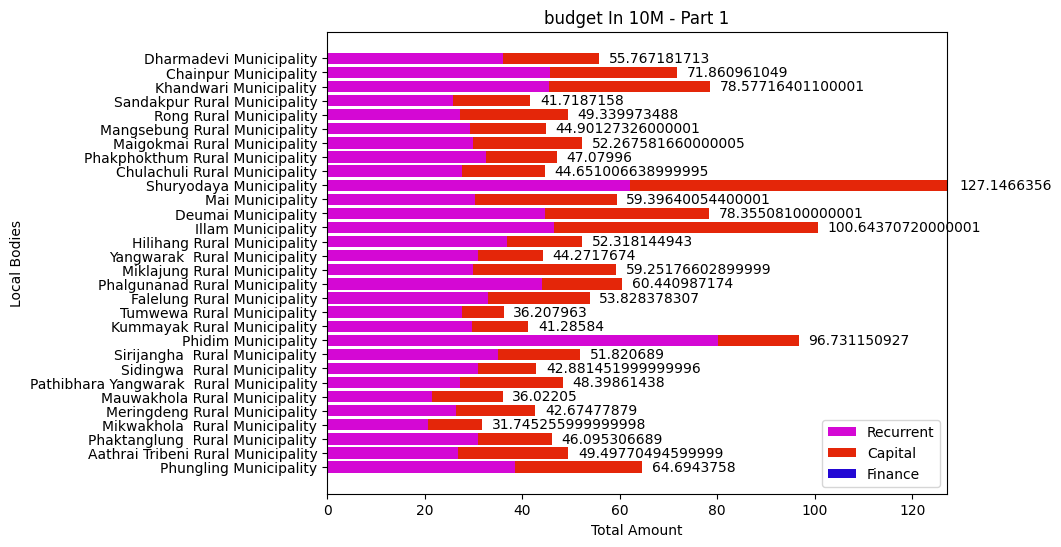

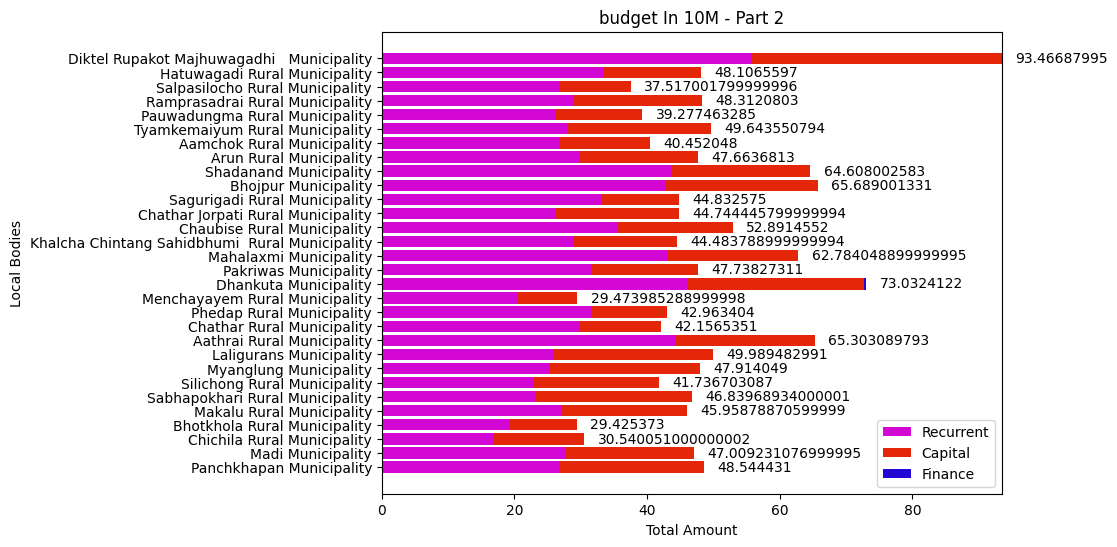

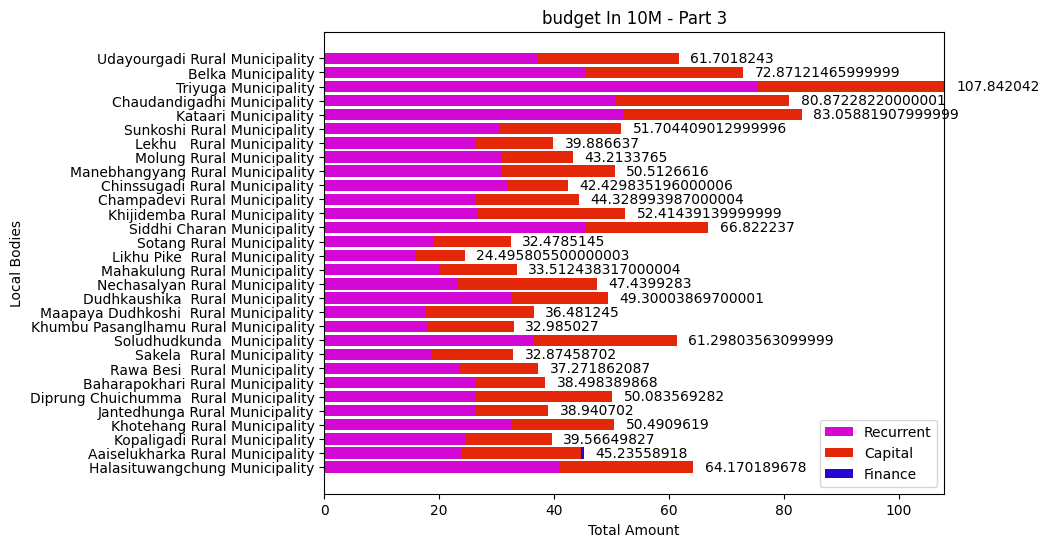

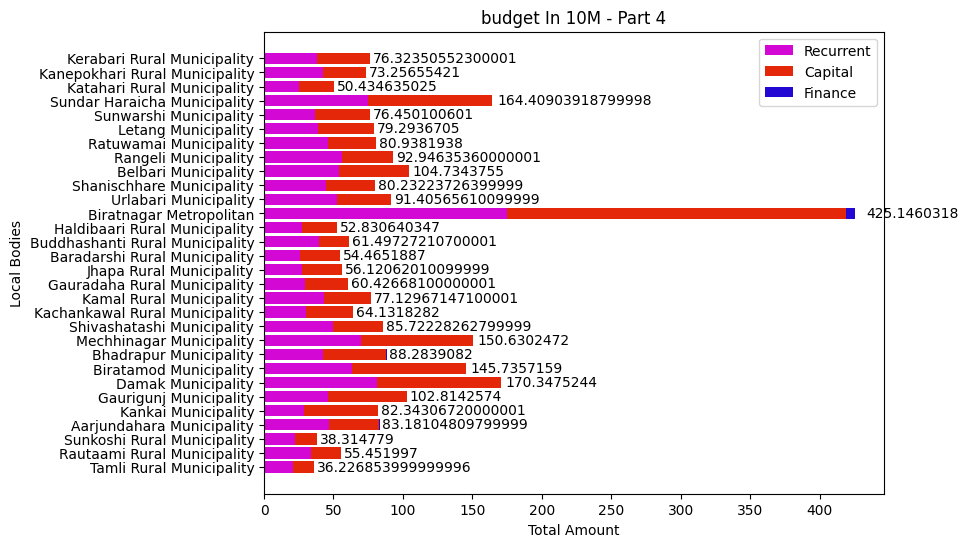

In [15]:
composition_analysis = CompositionAnalysis(dataframe=budget_df_all, 
                                           title="budget", 
                                           total_attributes_limit=120, 
                                           bar_limit=30,
                                           bar_colors=color_dict)
# total_attributes_limit can be adjusted 
# total_attributes_limit/bar_limit = number of images
composition_analysis.plot_composition_bar()

**Observation**: 
- The budget composition is dominated by Recurrent and Capital categories.


In [16]:
color_dict = {
            'Recurrent': '#d42a08',
            'Capital': '#08d427',
            'Financial': '#a808d4'
        }
# can be passed as argument 

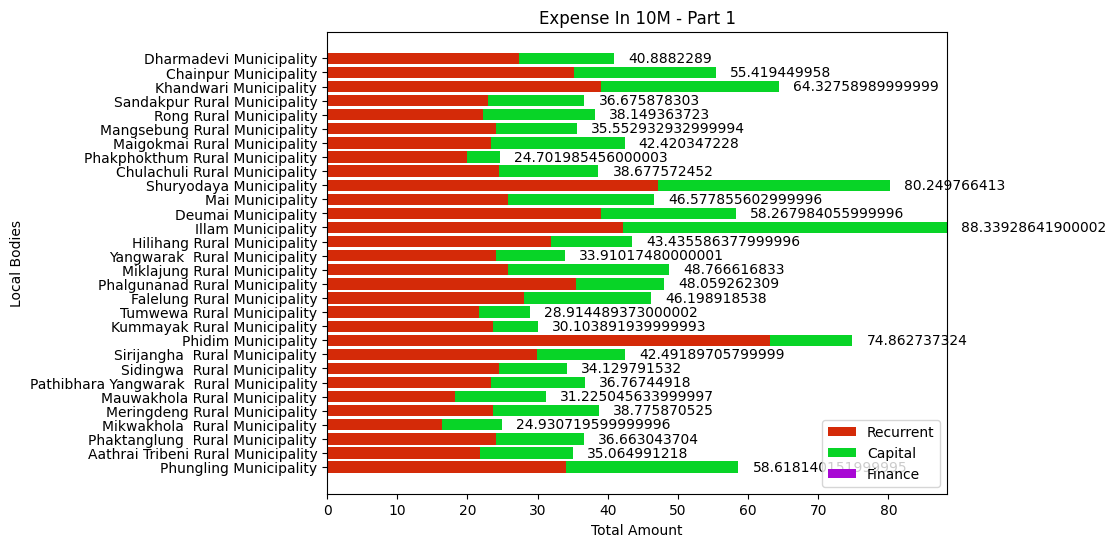

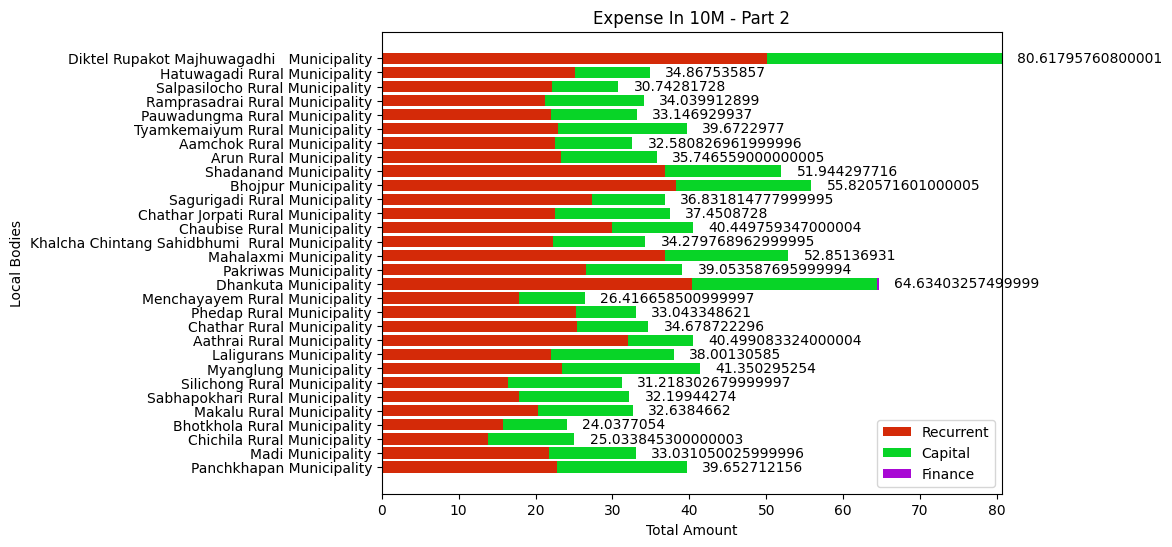

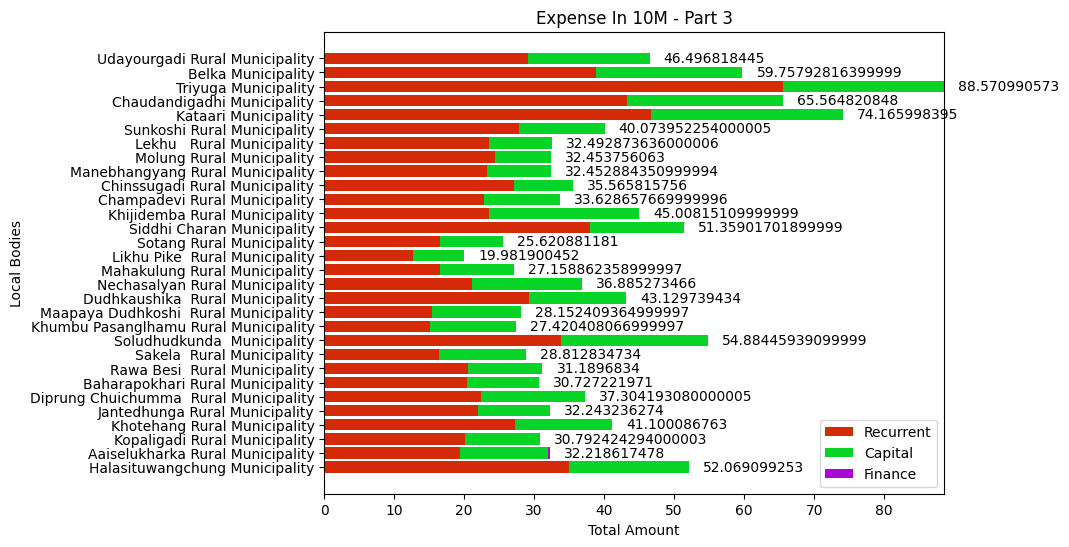

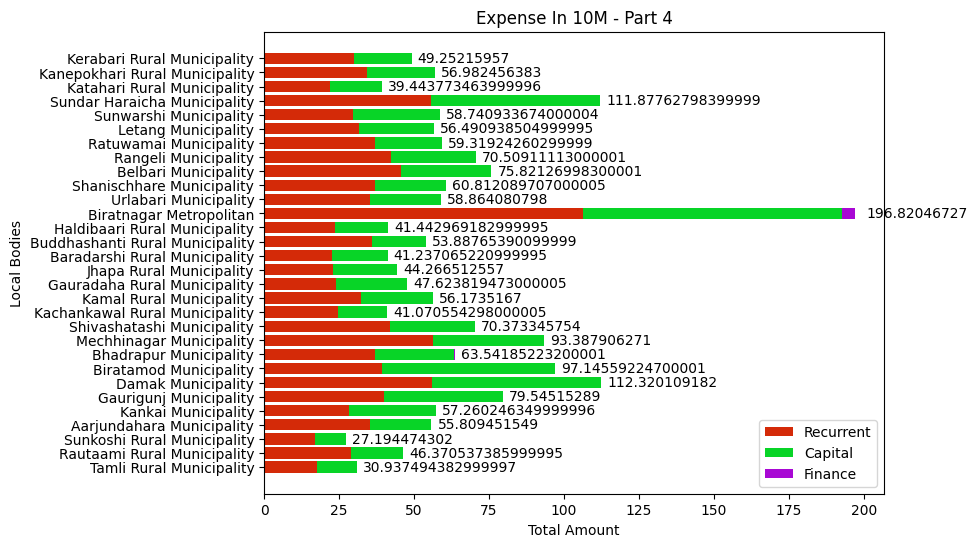

In [17]:
composition_analysis = CompositionAnalysis(dataframe=expense_df_all, 
                                           title="Expense", 
                                           total_attributes_limit=120, 
                                           bar_colors=color_dict,
                                           bar_limit=30)
composition_analysis.plot_composition_bar()

**Observation**: 
- Expense composition shows Recurrent and Capital as the main components.

In [18]:
rename_dict = {"Province" : "Local Body"}
# Renamed just to match PerformanceAnalysis class argument
budget_df_total_renamed = budget_df_total.rename(columns=rename_dict).copy()
expense_df_total_renamed = expense_df_total.rename(columns=rename_dict)
budget_df_total_renamed.head()

,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0).infer_objects(copy=False)


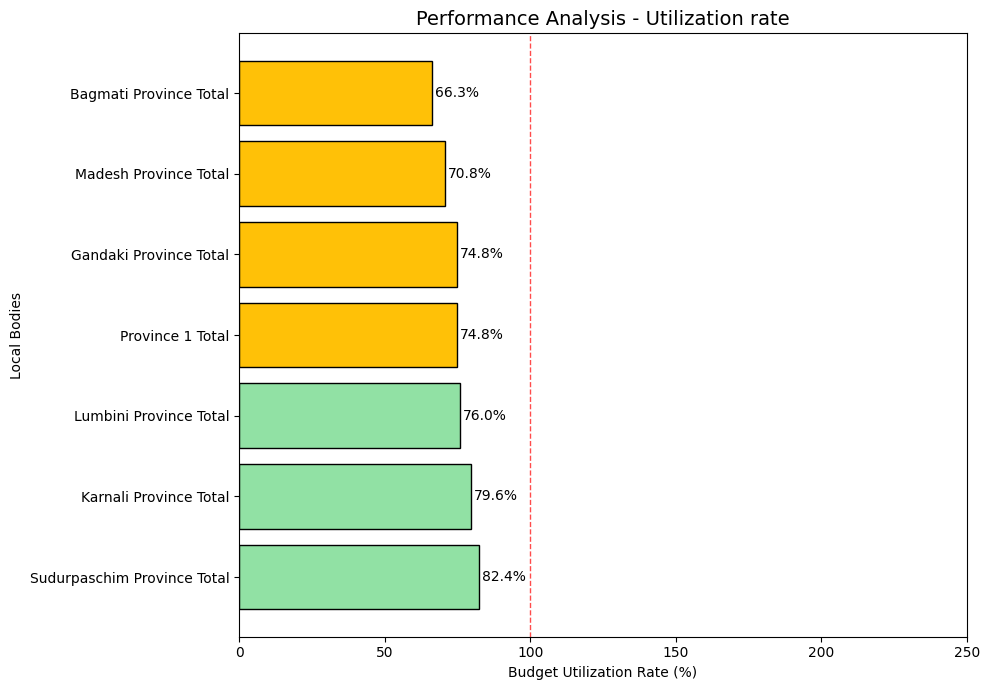

In [19]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df_total_renamed,
                                           dataframe_expense=expense_df_total_renamed,
                                           bar_limit=7,
                                           total_attributes_limit=7)
performance_analysis.plot_utilization_bar()

# Conclusion from the Performance Analysis - Utilization Rate Chart (Provincial Level)

The bar chart shows Budget Utilization Rates across the seven provinces of Nepal, ranging from **66.3% to 82.4%**.

## Key Observations:

### Highest Performers (Green Zone – Above 75%):
- **Sudurpashchim Province**: 82.4% (Highest)
- **Karnali Province**: 79.6%
- **Lumbini Province**: 76.0%

These three western and far-western provinces lead in budget execution efficiency.

### Good Performers (Yellow Zone – 50% to 75%):
- **Province 1** and **Gandaki Province**: Both at **74.8%**
  
Strong performance, just below the top tier.

### Moderate Performers:
- **Madhesh Province**: 70.8%
- **Bagmati Province**: 66.3% (Lowest)

## Final Conclusion:
- **Sudurpashchim Province** excels with the highest budget utilization at **82.4%**, followed closely by **Karnali** and **Lumbini**.
- **Bagmati Province** — home to the capital Kathmandu — has the lowest provincial utilization at **66.3%**, indicating systemic inefficiencies in the central region.
- **Western** and **far-western provinces** significantly outperform central and eastern provinces in fiscal discipline and project implementation.

### Insight:
Despite hosting the national capital and major economic hubs, **Bagmati Province** underperforms, while remote provinces like **Sudurpashchim** and **Karnali** show superior financial governance.


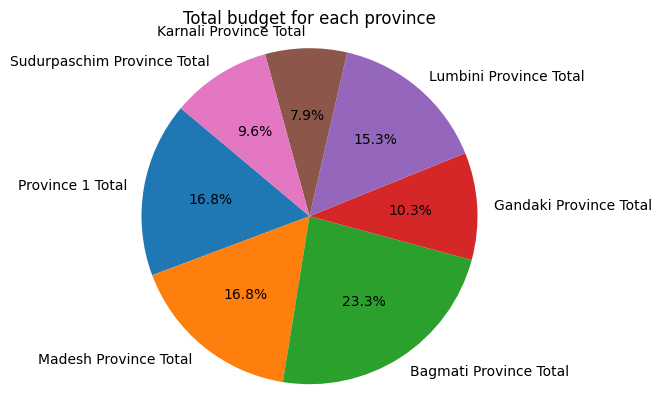

In [20]:
pie_charts = PieCharts(expense_frame=expense_df_all,
                       budget_frame=budget_df_all,
                       expense_total=expense_df_total,
                       budget_total=budget_df_total)
pie_charts.plot_for_total()

# Conclusion from the Pie Chart: **Total Budget Allocation by Province**

The pie chart displays the **percentage share of the total national budget** allocated to each of Nepal’s seven provinces.

## Key Observations:

| Province               | Budget Share |
|------------------------|--------------|
| **Bagmati Province**    | **23.3%** (Highest) |
| **Province 1**          | **16.8%** |
| **Madhesh Province**    | **16.8%** |
| **Lumbini Province**    | **15.3%** |
| **Gandaki Province**    | **10.3%** |
| **Sudurpashchim Province** | **9.6%** |
| **Karnali Province**    | **7.9%** (Lowest) |

---

### Final Conclusion:

> **Bagmati Province receives the largest budget share (23.3%)**, nearly **3 times that of Karnali (7.9%)**.  
>  
> **The three most populous and economically central provinces** — **Bagmati**, **Province 1**, and **Madhesh** — together account for **56.9%** of the total budget.  
>  
> **Remote and less-developed provinces** like **Karnali** and **Sudurpashchim** receive the smallest shares, despite **high poverty and infrastructure needs**.

---

### Critical Insight (Combining with above Utilization Data):

| Province               | Budget Share | Utilization Rate (Prev. Chart) |
|------------------------|--------------|-------------------------------|
| **Bagmati**            | 23.3% (Highest) | 66.3% (Lowest) |
| **Sudurpashchim**      | 9.6%          | **82.4%** (Highest) |
| **Karnali**            | 7.9% (Lowest) | 79.6% (2nd Highest) |

> **Bagmati gets the most money but utilizes it the least efficiently.**  
> **Sudurpashchim and Karnali get the least funding but achieve the highest utilization.**

---

### Policy Conclusion & Recommendation:

> **Nepal’s budget allocation is skewed toward central, urbanized regions, but execution efficiency is highest in remote western provinces.**  
>  
> **Inefficiency in Bagmati (especially Kathmandu) undermines national development impact despite high funding.**

**Recommendations:**
1. **Reform budget execution systems in Bagmati** – reduce delays, improve procurement, enhance monitoring.
2. **Study and replicate financial management practices** from **Sudurpashchim** and **Karnali**.
3. **Consider performance-based budget adjustments** – reward efficiency, not just population or political weight.

**Bottom Line**:  
> **More money ≠ Better outcomes.**  
> **Smaller, remote provinces are proving that good governance > big budgets.**


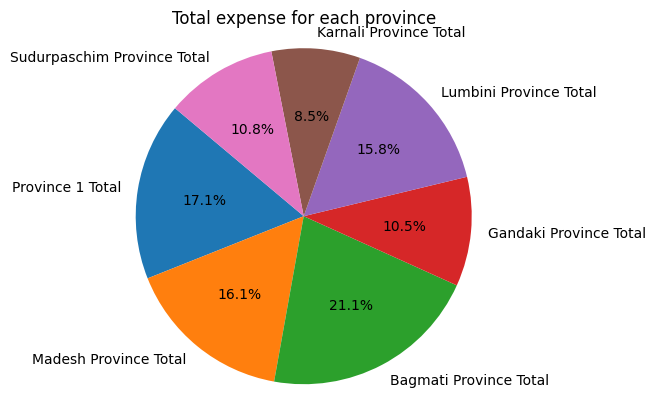

In [21]:
# For expense 
pie_charts.plot_for_total(type='expense')

### Final Conclusion

- **Bagmati Province** spent the most, accounting for **21.1%** of the total national expenditure.
- **Province 1** and **Madhesh Province** follow, with the central and eastern belt together accounting for **54.3%** of the total national expenditure.
- **Karnali Province** spent the least, at **8.5%**, despite having high developmental needs.


In [22]:
feature_extraction_urban = FeatureExtractionUrban(df=expense_df_all) # for all 753 local bodies
expense_df_urban_all = feature_extraction_urban.extract_urban_features().copy()
rows, column = expense_df_all.shape
print("Number of rows : ", rows)
expense_df_urban_all.head(rows)

Number of rows :  767


,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
385,382,Kathmandu Metropolitan,354.66311,207.934436,8.5,571.097545,983.660309
427,422,Pokhara Metropolitan,215.258805,153.555389,0.0,368.814193,135.404153
358,355,Bharatpur Metropolitan,147.603064,171.580025,0.0,319.183088,163.427313
379,376,Lalitpur Metropolitan,111.677921,175.020062,0.0,286.697984,181.757992
261,260,Birjung Metropolitan,126.035539,84.956164,0.0,210.991703,51.231338
108,109,Biratnagar Metropolitan,106.329656,86.189002,4.30181,196.820467,46.12698
365,362,Hetauda Sub-Metropolitan,99.378983,83.797145,0.568287,183.744414,105.282164
568,561,Ghorahi Sub-Metropolitan,107.282697,73.116797,0.0,180.399494,33.644931
492,485,Butwal Sub-Metropolitan,71.628195,89.645037,0.6,161.873231,68.785717
569,562,Tulsipur Sub-Metropolitan,95.868249,60.524575,0.483074,156.875898,25.431784


In [23]:
feature_extraction_urban = FeatureExtractionUrban(df=budget_df_all)
budget_df_urban_all = feature_extraction_urban.extract_urban_features()

/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0).infer_objects(copy=False)


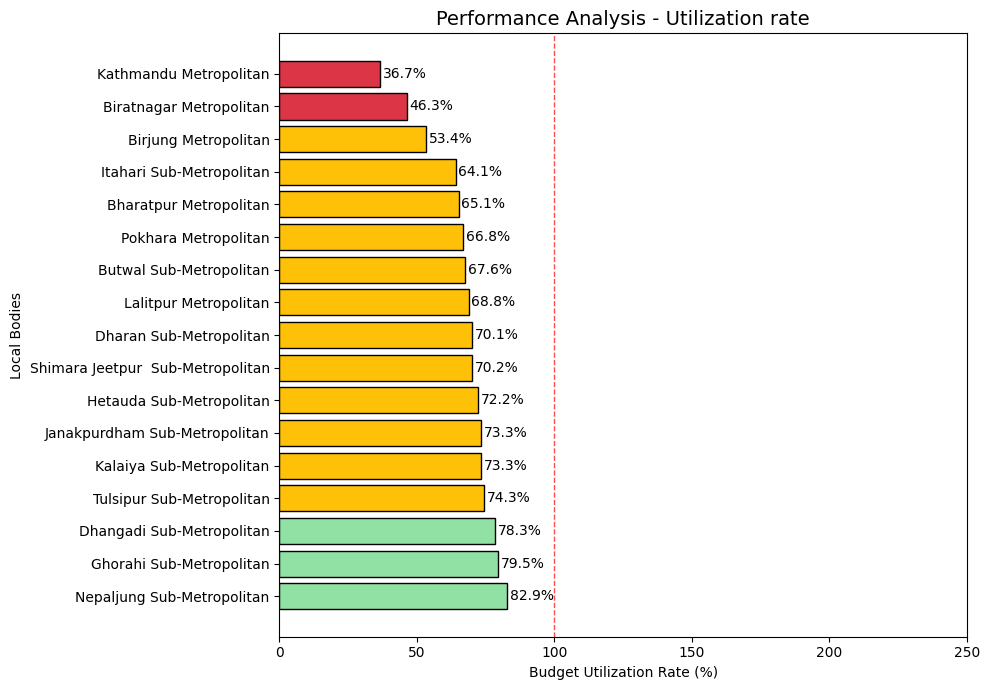

In [24]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df_urban_all,
                                           dataframe_expense=expense_df_urban_all,
                                           bar_limit=17,
                                           total_attributes_limit=17)
performance_analysis.plot_utilization_bar()

### Conclusion from the Performance Analysis - Utilization Rate Chart

The bar chart illustrates Budget Utilization Rates across various Metropolitan and Sub-Metropolitan cities with rates ranging from **36.7% to 82.9%**.

### Key Observations:

### Highest Performers (Green Zone – Above 75%):
- **Nepaljung Sub-Metropolitan**: 82.9% (Highest utilization)
- **Ghorahi Sub-Metropolitan**: 79.5%
- **Dhangadi Sub-Metropolitan**: 78.3%

These three sub-metropolitan bodies demonstrate excellent budget execution, utilizing over **78%** of allocated funds.

### Good Performers (Yellow Zone – 50% to 75%):
11 local bodies fall in this range, including:
- **Tulsipur**
- **Kalaiya**
- **Janakpurdham**
- **Hetauda**
  

### Moderate Performers (Yellow Zone – 53.4% to 65.1%):
Cities like **Pokhara**, **Bharatpur**, **Itahari**, and **Birjung** show moderate efficiency, with utilization between **53.4%** and **66.8%**.

### Lowest Performers (Red Zone – Below 50%):
- **Biratnagar Metropolitan**: 46.3%
- **Kathmandu Metropolitan**: 36.7% (Lowest utilization)

Major metropolitan cities are significantly underutilizing budgets, raising concerns about planning, execution, or administrative bottlenecks.

### Overall Conclusion:
Smaller sub-metropolitan bodies (especially **Nepaljung**, **Ghorahi**, and **Dhangadi**) are far more efficient in budget utilization than larger metropolitan cities like **Kathmandu** and **Biratnagar**. **Kathmandu Metropolitan** has the poorest performance at only **36.7%**, despite being the capital and receiving substantial funding.


# FINAL CONCLUSION  
**Nepal’s Fiscal Performance :s**

---

## **1. The Big Picture**

| Province / City         | Budget Share | Expense Share | Utilization Rate | **Efficiency Score** |
|-------------------------|--------------|---------------|------------------|----------------------|
| **Sudurpashchim**        | 9.6%         | 10.8%         | **82.4%**        | ⭐⭐⭐⭐⭐               |
| **Karnali**              | 7.9%         | 8.5%          | **79.6%**        | ⭐⭐⭐⭐                |
| **Lumbini**              | 15.3%        | 15.8%         | 76.0%            | ⭐⭐⭐                 |
| **Province 1**           | 16.8%        | 17.1%         | 74.8%            | ⭐⭐⭐                 |
| **Gandaki**              | 10.3%        | 10.5%         | 74.8%            | ⭐⭐⭐                 |
| **Madhesh**              | 16.8%        | 16.1%         | 70.8%            | ⭐⭐                  |
| **Bagmati**              | **23.3%**    | 21.1%         | **66.3%**        | ⭐                   |

| **Top Local Performers**        | Utilization |
|----------------------------------|-------------|
| Nepaljung Sub-Metropolitan       | **82.9%**   |
| Ghorahi Sub-Metropolitan         | 79.5%       |
| Dhangadi Sub-Metropolitan        | 78.3%       |

| **Worst Local Performers**       | Utilization |
|----------------------------------|-------------|
| **Kathmandu Metropolitan**      | **36.7%**   |
| **Biratnagar Metropolitan**     | **46.3%**   |

---

## **THE CORE FINDING**

> **Nepal’s development engine runs best in the west — not in Kathmandu.**

- **The poorest, most remote provinces** (**Sudurpashchim** & **Karnali**) receive **less than 18% of the budget combined**, yet achieve **over 80% utilization**.
- **Bagmati Province**, home to the capital, receives **23.3% of the budget** but **fails to spend 1 in 3 rupees** efficiently (only **66.3% utilized**).
- **Kathmandu Metropolitan**, the nation’s economic heart, has the **lowest utilization in the country** at **36.7%**, even worse than many rural sub-metropolitans.

---

## **Key Insights**

| Insight                           | Evidence |
|-----------------------------------|---------|
| **1. Size ≠ Efficiency**          | Largest cities (Kathmandu, Biratnagar) = **worst performers**<br>Smaller sub-metros (Nepaljung, Ghorahi) = **best performers** |
| **2. Poverty ≠ Inefficiency**     | Poorest provinces (Sudurpashchim, Karnali) = **highest execution** |
| **3. More Money = More Waste**    | Bagmati gets **3x more than Karnali** but uses **13% less efficiently** |
| **4. Western Nepal Leads**        | Top 3 provinces in utilization: **Sudurpashchim, Karnali, Lumbini** |
| **5. Kathmandu is the Bottleneck**| Capital city’s **36.7% utilization drags down Bagmati’s 66.3%** |

---

## **The Nepal Paradox**

> **The center hoards funds. The periphery delivers results.**

- **Unspent funds in Kathmandu** could build **entire districts** in Sudurpashchim.
- **Every 1% improvement in Kathmandu’s utilization** = **tens of crores** in real development.
- **Every rupee in Nepaljung goes 2.3x further** than in Kathmandu.

---

## **FINAL VERDICT**

> **Good governance has migrated west.**  
> **Inefficiency is centralized in the capital.**

Nepal’s federalism is working — **but only where bureaucracy is light and accountability is high.**

---

## **One-Line Summary**

> **Kathmandu gets the gold. Nepaljung delivers the goods.**  
> **It’s time to follow the money — and the results.**
